In [310]:
import numpy as np
import QuantLib as ql
import matplotlib.pyplot as plt
import numpy as np

In [311]:

def SABR_implied_vol(strike, forward, expiry, alpha, beta, rho, nu):
    if forward <= 0 or strike <= 0 or expiry <= 0:
        return 0.0
    if alpha <= 0 or nu <0:
        return 0.0
    
    one_minus_beta =1.0-beta
    F_K = forward * strike
    log_F_K = np.log(forward / strike)
    
    if abs(forward - strike)<1e-8:
        term1 = alpha/ (forward**one_minus_beta)
        term2 = 1 + (
            (one_minus_beta**2 / 24) * (alpha**2 / (forward**(2*one_minus_beta)))+
            (0.25 * rho * beta * nu * alpha / (forward**one_minus_beta))+
            ((2-3 * rho**2) / 24) * nu**2
        ) * expiry
        return term1 * term2

    z = (nu / alpha)* (F_K ** (one_minus_beta / 2.0))* log_F_K
    
    if abs(z) < 1e-6:
        z_over_xz= 1.0
    else:
        x_z= np.log((np.sqrt(1 - 2 * rho * z + z**2) + z - rho) / (1 - rho))
        z_over_xz= z / x_z

    denominator = (F_K ** (one_minus_beta / 2.0)) * (
        1 + (one_minus_beta**2 / 24.0) *(log_F_K**2)+ 
        (one_minus_beta**4 / 1920.0) *(log_F_K**4)
    )
    
    correction = 1 + (
        (one_minus_beta**2 / 24.0) * (alpha**2 / (F_K**one_minus_beta))+
        (0.25 * rho* beta* nu* alpha / (F_K**(one_minus_beta / 2.0)))+
        ((2-3 * rho**2) / 24.0) * nu**2
    ) * expiry

    return (alpha / denominator) * z_over_xz * correction

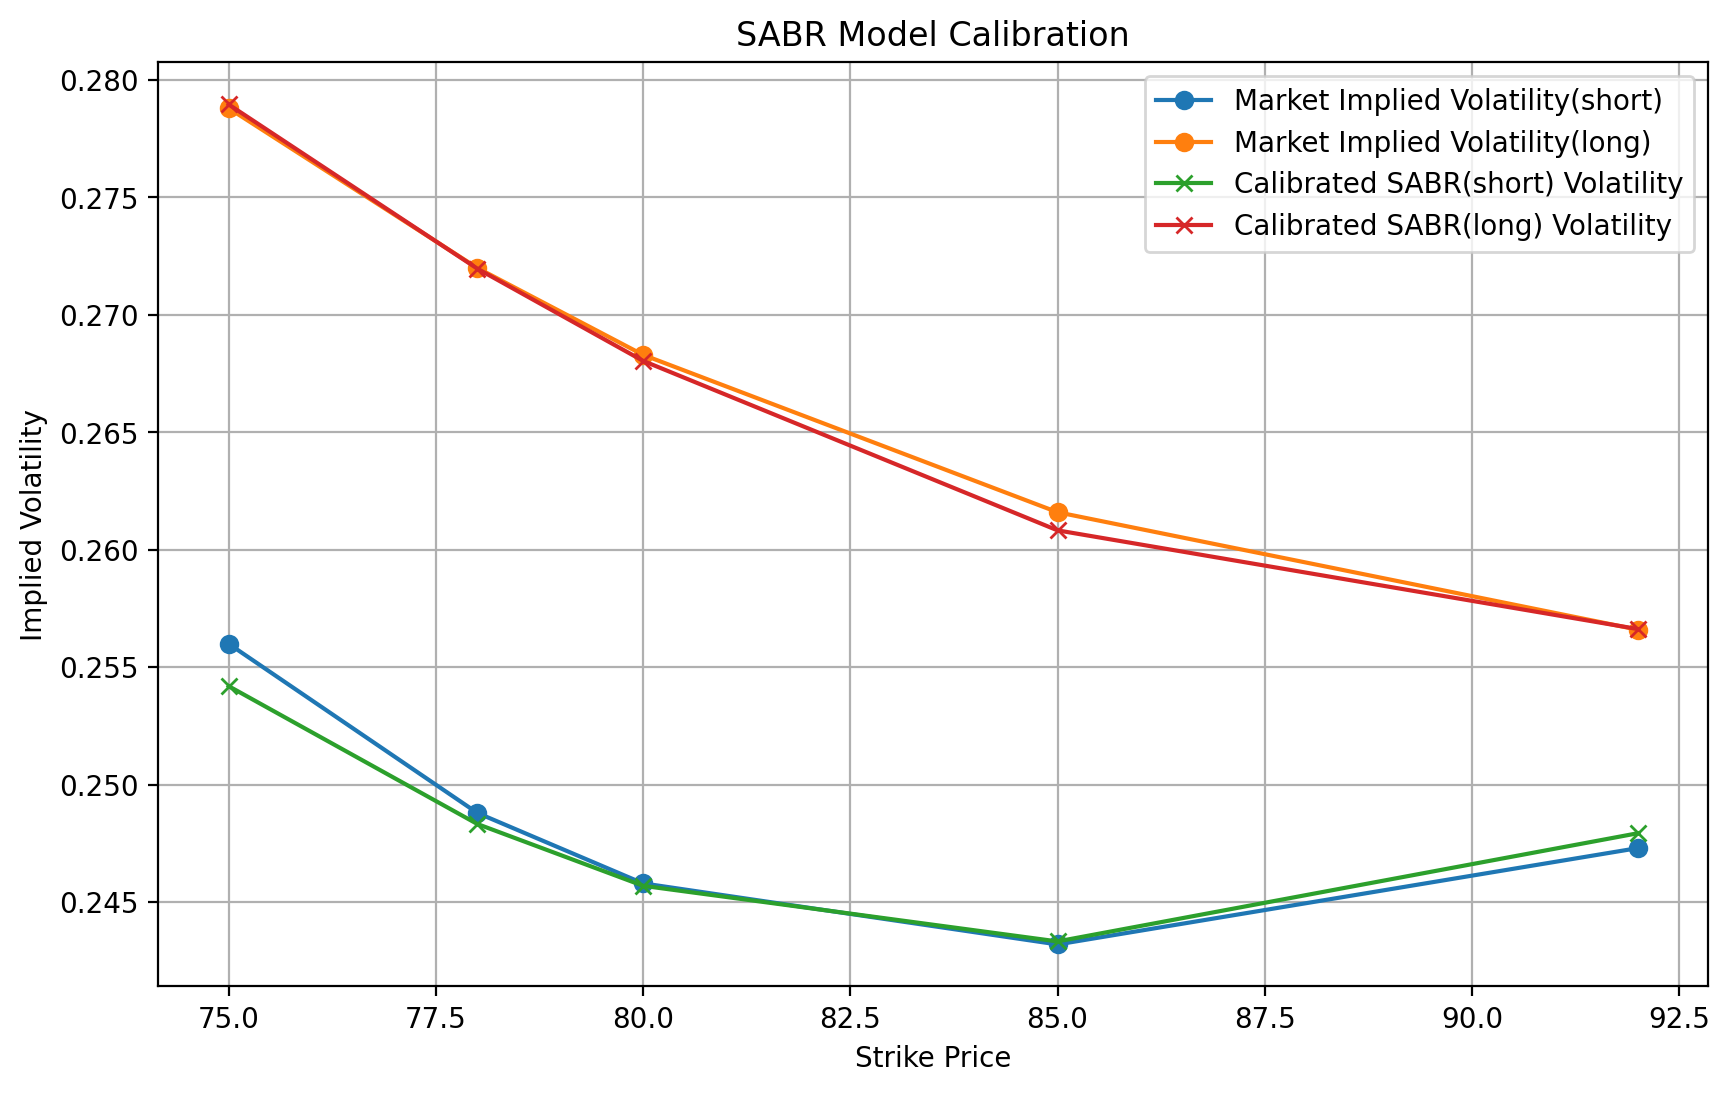

In [312]:
# SABR_volatility ICE EUA Dec.26 Option Calibration Parameters
spot_short = 75.13
spot_long = 78.31
r = [0.01930, 0.02300, 0.02585, 0.02775, 0.02730] # 17/05/2026 1M, 3M, 6M, 1Y, 3Y ESTR rate
expiration_date = [ql.Date(26, ql.December, 2026),
                    ql.Date(26, ql.December, 2027)]
calculation_date = ql.Date(17, ql.May, 2026)
time_to_expiry_short = (expiration_date[0] - calculation_date) / 365
time_to_expiry_long = (expiration_date[1] - calculation_date) / 365
risk_free_rate_dates = [ql.Date(26, ql.May, 2026),
                        ql.Date(26, ql.August, 2026),
                        ql.Date(26, ql.November, 2026),
                        ql.Date(26, ql.May, 2027),
                        ql.Date(26, ql.May, 2029)]
risk_free_rate_values = r
risk_free_curve = ql.ZeroCurve(risk_free_rate_dates, risk_free_rate_values, ql.Actual365Fixed())
discount_factor_short = risk_free_curve.discount(expiration_date[0])
discount_factor_long = risk_free_curve.discount(expiration_date[1])
day_count = ql.Actual365Fixed()
calendar = ql.NullCalendar()
Forward_price_short = spot_short / discount_factor_short
Forward_price_long = spot_long / discount_factor_long
strikes = [75, 78, 80, 85, 92]
alpha_short = 0.925
beta_short = 0.69
rho_short = -0.22
nu_short = 1.0
alpha_long = 0.97
beta_long = 0.69
rho_long = -0.2
nu_long = 0.8
data =[[0.2560, 0.2488, 0.2458, 0.2432, 0.2473],
       [0.2788, 0.2720, 0.2683, 0.2616, 0.2566]]

calibrated_vols_short_sabr = []
calibrated_vols_long_sabr = []

for strike in strikes:
    vol_short = SABR_implied_vol(
        strike, 
        Forward_price_short,    
        time_to_expiry_short,  
        alpha_short, beta_short, rho_short, nu_short 
    )
    calibrated_vols_short_sabr.append(vol_short)
    
    vol_long = SABR_implied_vol(
        strike, 
        Forward_price_long,     
        time_to_expiry_long,    
        alpha_long, beta_long, rho_long, nu_long  
    )
    calibrated_vols_long_sabr.append(vol_long)

plt.figure(figsize=(10, 6), dpi=200)
plt.plot(strikes, data[0], label='Market Implied Volatility(short)', marker='o')
plt.plot(strikes, data[1], label='Market Implied Volatility(long)', marker='o')
plt.plot(strikes, calibrated_vols_short_sabr, label='Calibrated SABR(short) Volatility', marker='x')
plt.plot(strikes, calibrated_vols_long_sabr, label='Calibrated SABR(long) Volatility', marker='x')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.title('SABR Model Calibration')
plt.legend()
plt.grid()
plt.show()

In [313]:
print("Calibrated SABR Volatilities:")
for strike, vol in zip(strikes, calibrated_vols_long_sabr):   
    print(f"Strike: {strike}, Calibrated Volatility: {vol:.4f}")
    print(rho_long)
calibrated_vols = np.array(calibrated_vols_short_sabr)


Calibrated SABR Volatilities:
Strike: 75, Calibrated Volatility: 0.2790
-0.2
Strike: 78, Calibrated Volatility: 0.2720
-0.2
Strike: 80, Calibrated Volatility: 0.2680
-0.2
Strike: 85, Calibrated Volatility: 0.2608
-0.2
Strike: 92, Calibrated Volatility: 0.2566
-0.2


In [314]:
def HestonModel_MonteCarloSimulation (S0, mu_curve, v0, kappa, theta, sigma, rho, step):
    
    dt = 1/365


    MU  = np.array([0, 0])
    COV = np.matrix([[1, rho], [rho, 1]])
    W   = np.random.multivariate_normal(MU, COV, step)
    W_S = W[:,0]
    W_v = W[:,1]

    vt    = np.zeros(step)
    vt[0] = v0
    St    = np.zeros(step)
    St[0] = S0

    for t in range(1, step):
        current_time = t * dt
        current_mu = mu_curve.forwardRate(current_time, current_time, ql.Continuous).rate()
        vt[t] = np.maximum(vt[t-1] + kappa*(theta - vt[t-1])*dt + sigma*np.sqrt(np.abs(vt[t-1])*dt)*W_v[t], 0)
        St[t] = St[t-1] + current_mu*St[t-1]*dt + np.sqrt(np.abs(vt[t-1])*dt)*St[t-1]*W_S[t]
    return St

In [315]:

calibrated_vols_short_sabr = []
calibrated_vols_long_sabr = []

for strike in strikes:
    vol_short = SABR_implied_vol(
        strike, 
        Forward_price_short,    
        time_to_expiry_short,  
        alpha_short, beta_short, rho_short, nu_short 
    )
    
    calibrated_vols_short_sabr.append(vol_short)
    
    
    vol_long = SABR_implied_vol(
        strike, 
        Forward_price_long,    
        time_to_expiry_long,    
        alpha_long, beta_long, rho_long, nu_long   
    )
    calibrated_vols_long_sabr.append(vol_long)
vol_matrix = np.zeros((1, len(strikes)))
for row_idx in range(len(strikes)):
    vol_matrix[0][row_idx] = calibrated_vols_short_sabr[row_idx]


In [316]:
import numpy as np

strikes_short_arr = np.array(strikes)

atm_index = np.argmin(np.abs(strikes_short_arr - Forward_price_short))

print(f"當前碳權遠期價格 (Forward): {Forward_price_short}")
print(f"最接近 ATM 的履約價是: {strikes[atm_index]}，它的索引是: {atm_index}")

當前碳權遠期價格 (Forward): 76.29141939116272
最接近 ATM 的履約價是: 75，它的索引是: 0


In [317]:
short_atm_vol = calibrated_vols_short_sabr[atm_index]
v0 = short_atm_vol**2  

calibrated_rho = rho_short
calibrated_kappa = 3.0
calibrated_sigma = nu_short
calibrated_theta = v0

In [318]:
zero_curve_ts = ql.YieldTermStructureHandle(ql.ZeroCurve(risk_free_rate_dates, r, day_count, calendar))
dividend_yield_ts = ql.YieldTermStructureHandle(ql.FlatForward(calculation_date, 0.0, day_count))

In [319]:
Heston_process = ql.HestonProcess(
    zero_curve_ts,
    dividend_yield_ts,
    ql.QuoteHandle(ql.SimpleQuote(spot_short)),
    v0,
    calibrated_kappa,
    calibrated_theta,
    calibrated_sigma,
    calibrated_rho
)
Heston_model = ql.HestonModel(Heston_process)
AHE = ql.AnalyticHestonEngine(Heston_model)

In [320]:
engine = ql.HestonModelHandle(Heston_model)
HestonProcess = ql.HestonProcess(zero_curve_ts, dividend_yield_ts, ql.QuoteHandle(ql.SimpleQuote(spot_short)), v0, calibrated_kappa, calibrated_theta, calibrated_sigma, calibrated_rho)
Heston_model = ql.HestonModel(HestonProcess)
AHE = ql.AnalyticHestonEngine(Heston_model)

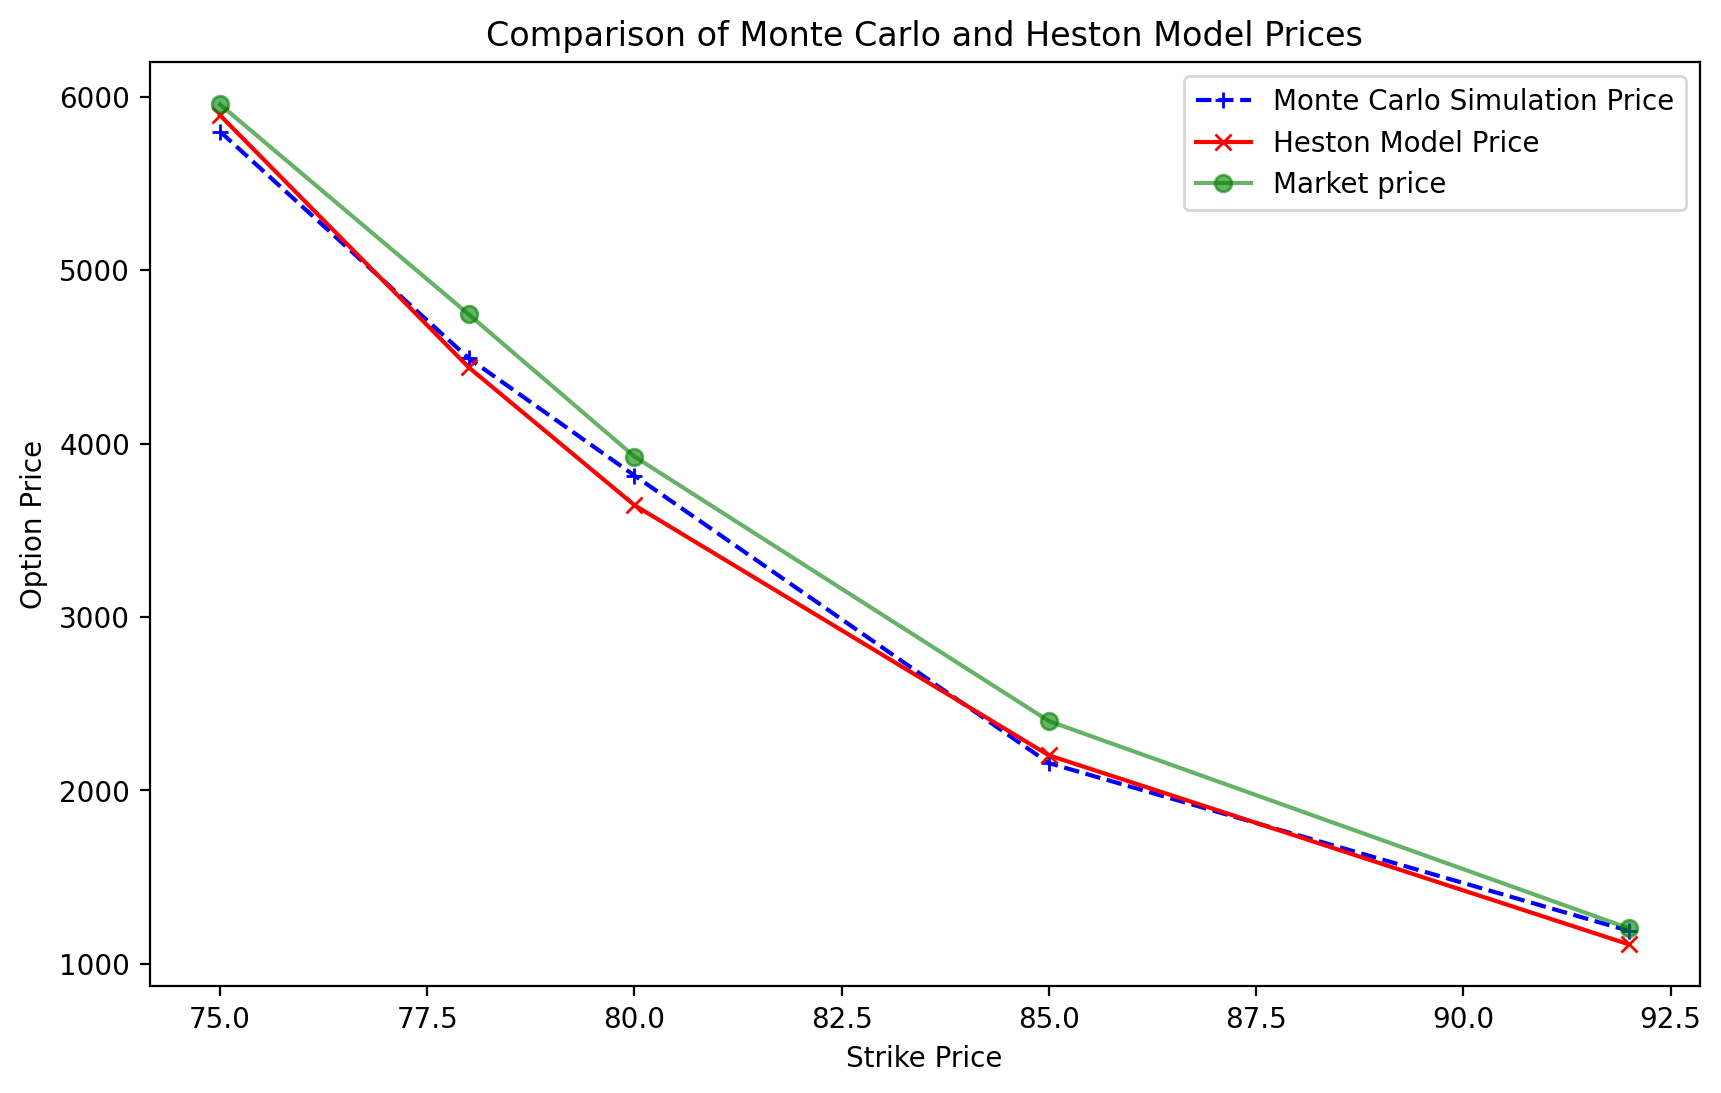

In [321]:
path = 10000          
step = 207             
market_prices_short = [5955, 4745, 3925, 2400, 1205]
simulations = []        
model = []              

for i in range(len(strikes)): 
    strike = strikes[i]
    
    europeanExercise = ql.EuropeanExercise(ql.Date(26, ql.December, 2026))
    payoff = ql.PlainVanillaPayoff(ql.Option.Call, strike)  
    option = ql.VanillaOption(payoff, europeanExercise)
    
    option.setPricingEngine(AHE) 
    
    model_price = option.NPV()
    model.append(model_price)
    
    S_T_values = np.zeros(path)
    
    for j in range(path):
        asset_path = HestonModel_MonteCarloSimulation(
            spot_short, risk_free_curve, v0, calibrated_kappa, calibrated_theta, calibrated_sigma, calibrated_rho, step
        )
        
        S_T_values[j] = asset_path[-1] 
        
    mc_payoffs = np.maximum(S_T_values - strike, 0.0)
    mc_price = discount_factor_short * np.mean(mc_payoffs)
    simulations.append(mc_price)
    
simulations_per_contract = np.array(simulations) * 1000
model_per_contract = np.array(model) * 1000
plt.figure(figsize=(10, 6), dpi=200)
plt.plot(strikes, simulations_per_contract, linestyle='--', label='Monte Carlo Simulation Price', color='blue', marker='+')
plt.plot(strikes, model_per_contract, linestyle='-', label='Heston Model Price', color='red', marker='x')
plt.plot(strikes, market_prices_short, linestyle='-', label='Market price', color='green', marker='o', alpha=0.6)
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.title('Comparison of Monte Carlo and Heston Model Prices')
plt.legend()
plt.show()

In [322]:
simulations_per_contract

array([5798.79264689, 4491.80386961, 3815.6446261 , 2157.7918605 ,
       1189.98397808])